# 05 — Parquet → LSTM-AE / LSTM-GMVAE (Pipeline único)

**Pipeline completo**: Parquet → Cluster Sampling (GPU) → Preprocesamiento → Tensores → LSTM Autoencoder (o GMVAE) → Embeddings.

Este notebook es el **único** necesario para el proyecto: carga datos, entrena el modelo y produce embeddings listos para usar en otros notebooks (análisis downstream, clustering, etc.).

**Optimizaciones:**
- Lectura solo de columnas necesarias (~60% menos I/O)
- Límite de particiones (56)
- Filtrado lazy con `map_partitions` (100% GPU)
- Preprocesamiento vectorizado (winsorizing, imputación, PowerTransformer)
- Cyclical annealing (Fu et al. 2019) para mitigar posterior collapse
- Salida: `Z`, `qy`, `cluster_assign`, `y_target` guardados en Drive para recarga en otros notebooks

## 1. Setup (Colab)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
!pip install -q --extra-index-url=https://pypi.nvidia.com cudf-cu12 dask-cudf-cu12 dask-cuda rmm-cu12
!pip install -q scikit-learn umap-learn
print('OK')

Mounted at /content/drive
NVIDIA A100-SXM4-80GB, 81920 MiB
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 230.9 MB/s eta 0:00:00
OK


In [2]:
import os, gc, random, time
import numpy as np
import pandas as pd
import cudf
import dask_cudf as dc
from dask.distributed import Client
from dask_cuda import LocalCUDACluster
from dask.utils import parse_bytes
from sklearn.preprocessing import PowerTransformer, MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder

DRIVE_BASE   = '/content/drive/MyDrive'
PARQUET_PATH = f'{DRIVE_BASE}/mortgage-risk/parquet/'
OUTPUT_DIR   = f'{DRIVE_BASE}/mortgage-risk/ae_input'
IMG_DIR      = f'{DRIVE_BASE}/mortgage-risk/figuras'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)
print(f'Figuras se guardarán en: {IMG_DIR}')

N_SAMPLE_LOANS = 5_000
N_PARTS_READ   = 56
MAX_SEQ_LEN    = 256
RANDOM_SEED    = 42
ID_COL         = 'Loan_Identifier'
LOAN_AGE_COL   = 'Loan_Age'
BLOCKSIZE      = '512MB'

gpu_mem_query = !nvidia-smi --query-gpu=memory.total --format=csv,noheader,nounits
GPU_MEM = int(gpu_mem_query[0].strip()) if gpu_mem_query else 16000
cluster = LocalCUDACluster(CUDA_VISIBLE_DEVICES='0', rmm_pool_size=parse_bytes(f'{int(GPU_MEM*0.8)}MB'))
client = Client(cluster)
print(f'GPU: {GPU_MEM} MB')

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:34207
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:39059'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:40669 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40669
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:52310
INFO:distributed.scheduler:Receive client connection: Client-05ad351e-177f-11f1-81ac-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:52318


GPU: 81920 MB


## 2. Columnas mínimas + Property_State (derivamos Property_State_Division)

In [3]:
COLS_READ = [
    ID_COL, LOAN_AGE_COL, 'Property_State',
    'Current_Interest_Rate', 'Current_Actual_UPB', 'Remaining_Months_to_Legal_Maturity',
    'Current_Loan_Delinquency_Status',  # Morosidad mensual (señal clave para riesgo temporal)
    'Original_Interest_Rate', 'Original_UPB', 'Original_Loan_Term',
    'Original_Loan_to_Value_Ratio_LTV', 'Debt-To-Income_DTI', 'Borrower_Credit_Score_at_Origination',
    'Channel', 'Loan_Purpose', 'Property_Type', 'Occupancy_Status', 'First_Time_Home_Buyer_Indicator',
    'Zero_Balance_Code',
]

# Mapeo ordinal: Current_Loan_Delinquency_Status (00=current, 01=30d, ..., XX=foreclosure)
DELINQUENCY_MAP = {'00':0,'01':1,'02':2,'03':3,'04':4,'05':5,'06':6,'07':7,'08':8,'09':9,'XX':9,'99':0}

STATE_TO_DIV = {
    'CT':'New_England','ME':'New_England','MA':'New_England','NH':'New_England','RI':'New_England','VT':'New_England',
    'NJ':'Middle_Atlantic','NY':'Middle_Atlantic','PA':'Middle_Atlantic',
    'IL':'East_North_Central','IN':'East_North_Central','MI':'East_North_Central','OH':'East_North_Central','WI':'East_North_Central',
    'IA':'West_North_Central','KS':'West_North_Central','MN':'West_North_Central','MO':'West_North_Central','NE':'West_North_Central','ND':'West_North_Central','SD':'West_North_Central',
    'DE':'South_Atlantic','DC':'South_Atlantic','FL':'South_Atlantic','GA':'South_Atlantic','MD':'South_Atlantic','NC':'South_Atlantic','SC':'South_Atlantic','VA':'South_Atlantic','WV':'South_Atlantic',
    'AL':'East_South_Central','KY':'East_South_Central','MS':'East_South_Central','TN':'East_South_Central',
    'AR':'West_South_Central','LA':'West_South_Central','OK':'West_South_Central','TX':'West_South_Central',
    'AZ':'Mountain','CO':'Mountain','ID':'Mountain','MT':'Mountain','NV':'Mountain','NM':'Mountain','UT':'Mountain','WY':'Mountain',
    'AK':'Pacific','CA':'Pacific','HI':'Pacific','OR':'Pacific','WA':'Pacific',
}

DYNAMIC_COLS = ['Current_Interest_Rate','Current_Actual_UPB','Remaining_Months_to_Legal_Maturity','Current_Loan_Delinquency_Status']
STATIC_NUM   = ['Original_Interest_Rate','Original_UPB','Original_Loan_Term','Original_Loan_to_Value_Ratio_LTV','Debt-To-Income_DTI','Borrower_Credit_Score_at_Origination']
STATIC_CAT   = ['Channel','Loan_Purpose','Property_Type','Occupancy_Status','First_Time_Home_Buyer_Indicator','Property_State_Division']
TARGET_COL   = 'Zero_Balance_Code'

WINSOR_DYN = {'Current_Interest_Rate':(2,10.5),'Current_Actual_UPB':(0,385000),'Remaining_Months_to_Legal_Maturity':(0,480)}
WINSOR_STAT = {'Original_UPB':(25000,248000),'Original_Interest_Rate':(6.25,8.875),'Borrower_Credit_Score_at_Origination':(570,804),'Original_Loan_to_Value_Ratio_LTV':(24,97),'Debt-To-Income_DTI':(8,62),'Original_Loan_Term':(120,360)}

## 3. Lectura Parquet + Sampling (GPU)

In [4]:
SAMPLE_FILE_PATH = f'{DRIVE_BASE}/mortgage-risk/sample/sample_history.parquet'

if os.path.exists(SAMPLE_FILE_PATH):
    ddf = None
    n_parts = 0
    print('[Parquet] sample_history.parquet existe. Se omitirá la lectura del Parquet completo.')
else:
    ddf = dc.read_parquet(
        PARQUET_PATH,
        split_row_groups=True,
        index=False,
        dataset={"partitioning": None}
    )
    n_parts = min(N_PARTS_READ, ddf.npartitions)
    print(f'[Parquet] Cargado: {n_parts} particiones')



[Parquet] sample_history.parquet existe. Se omitirá la lectura del Parquet completo.


In [5]:
if os.path.exists(SAMPLE_FILE_PATH):
    # ==========================================================
    # Carga desde Drive (muestra preexistente)
    # ==========================================================
    print('[Carga] Usando muestra preexistente en Drive.')
    sample_pd = pd.read_parquet(SAMPLE_FILE_PATH).reset_index(drop=True)
else:
    # ==========================================================
    # Muestreo desde Parquet (estratificado: incluir Default 06/09)
    # ==========================================================
    N_PARTS_SCAN = min(30, ddf.npartitions)
    ddf_scan = ddf.partitions[0:N_PARTS_SCAN]

    # FASE 1: Pool global + IDs con Default (Zero_Balance_Code 06 o 09)
    print(f'[FASE 1] Extrayendo pool de {N_PARTS_SCAN} particiones...')
    pool_cu = ddf_scan[ID_COL].unique().compute()
    n_pool = len(pool_cu)
    if TARGET_COL in ddf_scan.columns:
        default_cu = ddf_scan[ddf_scan[TARGET_COL].isin(['06','09'])][ID_COL].unique().compute()
        default_ids = set(default_cu.to_pandas().tolist())
        n_default = len(default_ids)
        print(f'  Pool: {n_pool:,} préstamos | Default (06/09): {n_default:,}')
    else:
        default_ids = set()
        n_default = 0
        print(f'  Pool: {n_pool:,} préstamos únicos')

    # Muestreo estratificado: priorizar Default, completar con aleatorios
    n_default_select = min(500, n_default)
    n_rest = min(N_SAMPLE_LOANS - n_default_select, n_pool - n_default_select)
    n_rest = max(0, n_rest)
    pool_list = pool_cu.to_pandas().tolist()
    random.seed(RANDOM_SEED)
    if default_ids and n_default_select > 0:
        ids_default = list(default_ids)[:n_default_select] if n_default_select >= len(default_ids) else random.sample(list(default_ids), n_default_select)
        pool_no_default = [x for x in pool_list if x not in default_ids]
        ids_rest = random.sample(pool_no_default, n_rest) if len(pool_no_default) >= n_rest else pool_no_default
        ids_list = ids_default + ids_rest
        print(f'  Seleccionados: {len(ids_default):,} Default + {len(ids_rest):,} No-Default = {len(ids_list):,}')
    else:
        n_select = min(N_SAMPLE_LOANS, n_pool)
        ids_list = random.sample(pool_list, n_select)
        print(f'  Conglomerados seleccionados: {len(ids_list):,} Loan_Identifiers')

    del pool_cu
    gc.collect()

    # FASE 2: Filtrado Paralelo (Historia Completa)
    print(f'\n[FASE 2] Descargando historia completa en paralelo...')
    ddf_filtered = ddf_scan[ddf_scan[ID_COL].isin(ids_list)]
    sample_cu = ddf_filtered.compute().reset_index(drop=True)
    sample_pd = sample_cu.to_pandas().reset_index(drop=True)

    del sample_cu
    gc.collect()

    # FASE 3: Guardar en Drive
    SAMPLE_DIR = f'{DRIVE_BASE}/mortgage-risk/sample'
    os.makedirs(SAMPLE_DIR, exist_ok=True)
    sample_pd.to_parquet(SAMPLE_FILE_PATH, engine='pyarrow', index=False)
    print(f'\n[FASE 3] Muestra guardada: {SAMPLE_FILE_PATH}')

# Property_State_Division (derivado si no existe)
if 'Property_State_Division' not in sample_pd.columns and 'Property_State' in sample_pd.columns:
    sample_pd['Property_State_Division'] = sample_pd['Property_State'].astype(str).str.strip().str.upper().str[:2].map(
        lambda x: STATE_TO_DIV.get(x,'Unknown') if x and len(x)==2 else 'Unknown'
    )

sample_pd = sample_pd.reset_index(drop=True)
print(f'\nMuestra lista: {len(sample_pd):,} filas | {sample_pd[ID_COL].nunique():,} préstamos')

[Carga] Usando muestra preexistente en Drive.

Muestra lista: 184,503 filas | 5,000 préstamos


In [6]:
# El guardado de la muestra se realiza en la celda anterior (FASE 3 al muestrear).
# Si se cargó desde Drive, la muestra ya está en memoria.
print(f'Muestra en memoria: {len(sample_pd):,} filas | {sample_pd.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Muestra en memoria: 184,503 filas | 362.14 MB


## 4. Preprocesamiento vectorizado → Tensores

In [7]:
# Diagnóstico opcional: ejecutar DESPUÉS de la celda de preprocesamiento
if 'X_num' in globals() and 'num_cols' in globals():
    print('X_num dtype:', X_num.dtype, '| shape:', X_num.shape)
    print('NaNs:', np.isnan(X_num).sum(), '| Infs:', np.isinf(X_num).sum())
    stats = pd.DataFrame({'min': X_num.min(0), 'max': X_num.max(0), 'mean': X_num.mean(0)}, index=num_cols)
    print(stats)
else:
    print('Ejecuta primero la celda de preprocesamiento (Sección 4).')

Ejecuta primero la celda de preprocesamiento (Sección 4).


In [8]:
df_seq = sample_pd[sample_pd[LOAN_AGE_COL]>=0].copy().reset_index(drop=True)
df_seq[LOAN_AGE_COL] = df_seq[LOAN_AGE_COL].astype(int)

for c,(lo,hi) in WINSOR_DYN.items():
    if c in df_seq.columns: df_seq[c] = df_seq[c].clip(lo, hi)
for c,(lo,hi) in WINSOR_STAT.items():
    if c in df_seq.columns: df_seq[c] = df_seq[c].clip(lo, hi)

# Current_Loan_Delinquency_Status: codificación ordinal (0=current, 1-9=mora)
if 'Current_Loan_Delinquency_Status' in df_seq.columns:
    df_seq['Current_Loan_Delinquency_Status'] = df_seq['Current_Loan_Delinquency_Status'].astype(str).str.strip().map(lambda x: DELINQUENCY_MAP.get(x, 0)).fillna(0).astype(np.float32).clip(0, 9)
else:
    df_seq['Current_Loan_Delinquency_Status'] = 0.0

for c in DYNAMIC_COLS:
    if c in df_seq.columns: df_seq[c] = df_seq[c].fillna(df_seq[c].median())

df_static = sample_pd.drop_duplicates(subset=[ID_COL], keep='first').reset_index(drop=True)
for c,(lo,hi) in WINSOR_STAT.items():
    if c in df_static.columns: df_static[c] = df_static[c].clip(lo, hi)
num_cols = [c for c in STATIC_NUM if c in df_static.columns]
if not num_cols:
    raise ValueError('Ninguna columna estática numérica encontrada. Verifica que sample_pd tenga: ' + str(STATIC_NUM))
X_num = df_static[num_cols].fillna(df_static[num_cols].median()).values.astype(np.float64)
X_num = np.nan_to_num(X_num, nan=0.0, posinf=0.0, neginf=0.0)
scaler_static = StandardScaler()
X_num = scaler_static.fit_transform(X_num).astype(np.float32)

cat_cols = [c for c in STATIC_CAT if c in df_static.columns]
X_cat = np.zeros((len(df_static), len(cat_cols)), dtype=np.int32)
for j, c in enumerate(cat_cols):
    le = LabelEncoder()
    X_cat[:, j] = le.fit_transform(df_static[c].fillna('UNK').astype(str).values)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_ohe = ohe.fit_transform(X_cat).astype(np.float32)
X_static = np.concatenate([X_num, X_cat_ohe], axis=1)

scaler = MinMaxScaler()
dyn_avail = [c for c in DYNAMIC_COLS if c in df_seq.columns]
df_seq[dyn_avail] = scaler.fit_transform(df_seq[dyn_avail].values)

n_loans = len(df_static)
n_static = X_static.shape[1]
INPUT_DIM = len(dyn_avail) + n_static

X_seq = np.zeros((n_loans, MAX_SEQ_LEN, INPUT_DIM), dtype=np.float32)
mask  = np.zeros((n_loans, MAX_SEQ_LEN), dtype=bool)
lid2idx = {lid:i for i,lid in enumerate(df_static[ID_COL].values)}
df_s = df_seq.sort_values([ID_COL, LOAN_AGE_COL])

for lid, grp in df_s.groupby(ID_COL):
    if lid not in lid2idx: continue
    i = lid2idx[lid]
    dyn = grp[dyn_avail].values[:MAX_SEQ_LEN].astype(np.float32)
    T = len(dyn)
    st = np.tile(X_static[i:i+1], (T, 1))
    X_seq[i, :T] = np.concatenate([dyn, st], axis=1)
    mask[i, :T] = True

lengths = mask.sum(axis=1).astype(np.int64)
lengths = np.maximum(lengths, 1)

# Target desde ÚLTIMA observación (Zero_Balance_Code se asigna al terminar el préstamo)
df_last = sample_pd.sort_values([ID_COL, LOAN_AGE_COL]).drop_duplicates(subset=[ID_COL], keep='last')
default_map = dict(zip(df_last[ID_COL], df_last[TARGET_COL].isin(['06','09']).astype(int)))
y_target = np.array([default_map.get(lid, 0) for lid in df_static[ID_COL].values], dtype=np.int32)

print(f'X_seq: {X_seq.shape} | lengths: {lengths.shape} | y_target: {y_target.shape}')
print(f'Input_dim: {INPUT_DIM} | Mask coverage: {mask.mean():.1%} | Default rate: {y_target.mean():.2%}')

X_seq: (5000, 256, 37) | lengths: (5000,) | y_target: (5000,)
Input_dim: 37 | Mask coverage: 13.9% | Default rate: 1.62%


## 5. Guardar y recargar

In [9]:
npz_path = f'{OUTPUT_DIR}/ae_input.npz'
np.savez_compressed(npz_path, X_seq=X_seq, lengths=lengths, y_target=y_target, mask=mask)
print(f'Guardado: {npz_path}')

# Recarga (para entrenamiento en otro notebook):
# data = np.load(f'{OUTPUT_DIR}/ae_input.npz')
# X_seq, lengths, y_target = data['X_seq'], data['lengths'], data['y_target']


Guardado: /content/drive/MyDrive/mortgage-risk/ae_input/ae_input.npz


## 6. Modelo: LSTM-GMVAE o LSTM Autoencoder

**Opción por defecto (USE_LSTM_AE=True):** LSTM Autoencoder determinístico.
- BiLSTM Encoder → proyección lineal → z → Decoder LSTM → Reconstrucción.
- Loss = MSE_masked (sin KL, evita posterior collapse).

**Alternativa (USE_LSTM_AE=False):** LSTM-GMVAE.
- BiLSTM Encoder → qy (clusters) → qz (μ, logvar) por cluster → Decoder LSTM → Reconstrucción.
- Loss = MSE_masked + KL(qz||prior_GM) + r_nent·entropy(qy)

### Interpretación (Fannie Mae) — Curvas de entrenamiento

**Loss total y reconstrucción:** La disminución del loss indica que el modelo aprende a reconstruir las trayectorias mensuales de los préstamos. En el contexto Fannie Mae, esto significa que el espacio latente Z captura la evolución temporal de variables clave: tasa de interés actual, UPB, meses restantes y **Current_Loan_Delinquency_Status** (morosidad mensual).

**Relevancia para riesgo crediticio:** Una reconstrucción precisa implica que Z codifica patrones de comportamiento de pago a lo largo del tiempo. Los préstamos con trayectorias similares (ej. morosidad creciente, prepago temprano) se proyectarán cerca en Z, permitiendo segmentación por perfil de riesgo dinámico.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.distributions import Normal

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

SEQ_LEN = MAX_SEQ_LEN
HIDDEN_DIM = 256
LATENT_DIM = 32
K_CLUSTERS = 6
N_LAYERS = 2
DROPOUT = 0.3
R_NENT = 1.0
BATCH_SIZE = 512
LR = 5e-5
N_EPOCHS = 80

# Alternativa: LSTM Autoencoder determinístico (evita posterior collapse del GMVAE)
USE_LSTM_AE = True


class LSTMSeqAE(nn.Module):
    """Autoencoder LSTM determinístico: BiLSTM Encoder -> z -> Decoder LSTM -> Reconstrucción.
    Sin KL ni clusters: evita posterior collapse. Loss = MSE_masked."""
    def __init__(self, input_dim, seq_len_max, hidden_dim, latent_dim, num_layers, dropout):
        super().__init__()
        self.input_dim = input_dim
        self.seq_len_max = seq_len_max
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        self.dropout = dropout

        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, bidirectional=True, batch_first=True, dropout=dropout)
        self.z_proj = nn.Linear(hidden_dim * 2, latent_dim)
        self.decoder_lstm = nn.LSTM(latent_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.decoder_out = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, lengths):
        batch_size, seq_len, _ = x.size()
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, _) = self.encoder_lstm(packed_x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=-1)
        z = self.z_proj(h)

        z_exp = z.unsqueeze(1).repeat(1, seq_len, 1)
        decoder_out, _ = self.decoder_lstm(z_exp)
        recon = self.decoder_out(decoder_out)
        return recon, z


def lstm_ae_loss(recon, x, lengths):
    """Loss MSE enmascarada para autoencoder determinístico."""
    batch_size, seq_len, input_dim = x.size()
    mask = (torch.arange(seq_len, device=x.device)[None, :] < lengths[:, None]).float().unsqueeze(-1)
    mse = (recon - x).pow(2) * mask
    denom = (mask.sum(dim=[1, 2]) * input_dim).clamp(min=1)
    return (mse.sum(dim=[1, 2]) / denom).mean()


class GMVAE(nn.Module):
    """LSTM-GMVAE: BiLSTM Encoder → qy (clusters) → qz (μ, logvar) por cluster → Decoder LSTM → Reconstrucción."""
    def __init__(self, input_dim, seq_len_max, hidden_dim, latent_dim, k, num_layers, dropout, r_nent, fixed_encoder_var=False):
        super().__init__()
        self.input_dim = input_dim
        self.seq_len_max = seq_len_max
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.k = k
        self.num_layers = num_layers
        self.dropout = dropout
        self.r_nent = r_nent
        self.fixed_encoder_var = fixed_encoder_var

        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, bidirectional=True, batch_first=True, dropout=dropout)
        self.qy_linear = nn.Linear(hidden_dim * 2, k)
        self.qz_mu = nn.ModuleList([nn.Linear(hidden_dim * 2, latent_dim) for _ in range(k)])
        self.qz_logvar = nn.ModuleList([nn.Linear(hidden_dim * 2, latent_dim) for _ in range(k)])
        self.prior_mu = nn.Parameter(torch.zeros(k, latent_dim))
        self.prior_logvar = nn.Parameter(torch.zeros(k, latent_dim))
        self.decoder_lstm = nn.LSTM(latent_dim + k, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.decoder_out = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, lengths):
        batch_size, seq_len, _ = x.size()
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, _) = self.encoder_lstm(packed_x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=-1)

        qy_logit = self.qy_linear(h)
        qy = F.softmax(qy_logit, dim=-1)

        mu = torch.stack([self.qz_mu[i](h) for i in range(self.k)], dim=1)
        if self.fixed_encoder_var:
            logvar = torch.zeros_like(mu)
        else:
            logvar = torch.stack([self.qz_logvar[i](h) for i in range(self.k)], dim=1)

        z = []
        for i in range(self.k):
            std = torch.exp(0.5 * logvar[:, i]).clamp(min=1e-6)
            eps = torch.randn_like(std)
            z.append(mu[:, i] + eps * std)
        z = torch.stack(z, dim=1)

        recon = []
        for i in range(self.k):
            y_onehot = F.one_hot(torch.full((batch_size,), i, device=x.device, dtype=torch.long), self.k).float().unsqueeze(1).repeat(1, seq_len, 1)
            z_exp = z[:, i].unsqueeze(1).repeat(1, seq_len, 1)
            decoder_input = torch.cat([z_exp, y_onehot], dim=-1)
            decoder_out, _ = self.decoder_lstm(decoder_input)
            recon.append(self.decoder_out(decoder_out))
        recon = torch.stack(recon, dim=1)

        return recon, qy, qy_logit, mu, logvar, z


def gmvae_loss(recon, x, qy, qy_logit, mu, logvar, prior_mu, prior_logvar, r_nent, lengths, beta=1.0):
    batch_size, seq_len, input_dim = x.size()
    mask = (torch.arange(seq_len, device=x.device)[None, :] < lengths[:, None]).float().unsqueeze(-1)

    recon_loss = 0.0
    for i in range(recon.size(1)):
        mse = (recon[:, i] - x).pow(2) * mask
        denom = (mask.sum(dim=[1, 2]) * input_dim).clamp(min=1)
        mse_per_sample = mse.sum(dim=[1, 2]) / denom
        recon_loss = recon_loss + (qy[:, i] * mse_per_sample).sum()
    recon_loss = recon_loss / batch_size

    kl_loss = 0.0
    for i in range(mu.size(1)):
        normal_q = Normal(mu[:, i], torch.exp(0.5 * logvar[:, i]).clamp(min=1e-6))
        normal_p = Normal(prior_mu[i], torch.exp(0.5 * prior_logvar[i]).clamp(min=1e-6))
        kl = torch.distributions.kl.kl_divergence(normal_q, normal_p)
        if kl.dim() > 1:
            kl = kl.sum(dim=-1)
        kl_loss = kl_loss + (qy[:, i] * kl).mean()

    entropy_qy = -(qy * (qy + 1e-10).log()).sum(dim=-1).mean()
    return recon_loss + beta * kl_loss + r_nent * entropy_qy, recon_loss, kl_loss


def encode_y(model, x, lengths):
    """Encode qy (asignación de cluster)."""
    model.eval()
    with torch.no_grad():
        _, qy, _, _, _, _ = model(x, lengths)
    return qy.cpu().numpy()


def encode_z(model, x, lengths):
    """Encode z ponderado por qy (GMVAE) o z directo (LSTM AE)."""
    model.eval()
    with torch.no_grad():
        out = model(x, lengths)
        if isinstance(model, LSTMSeqAE):
            return out[1].cpu().numpy()
        _, qy, _, _, _, z = out
        z_weighted = (qy.unsqueeze(-1) * z).sum(dim=1)
    return z_weighted.cpu().numpy()


def reconstruct(model, x, lengths):
    """Reconstrucción ponderada por qy."""
    model.eval()
    with torch.no_grad():
        recon, qy, _, _, _, _ = model(x, lengths)
        recon_weighted = (qy.unsqueeze(-1).unsqueeze(-1) * recon).sum(dim=1)
    return recon_weighted.cpu().numpy()


if USE_LSTM_AE:
    model = LSTMSeqAE(INPUT_DIM, SEQ_LEN, HIDDEN_DIM, LATENT_DIM, N_LAYERS, DROPOUT).to(DEVICE)
else:
    model = GMVAE(INPUT_DIM, SEQ_LEN, HIDDEN_DIM, LATENT_DIM, K_CLUSTERS, N_LAYERS, DROPOUT, R_NENT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo: {"LSTM-AE" if USE_LSTM_AE else "LSTM-GMVAE"} | Parámetros: {n_params:,}')

Dispositivo: cuda
Modelo: LSTM-AE | Parámetros: 3,030,341


### Interpretación (Fannie Mae) — Espacio latente UMAP

**Izquierda (clusters):** La proyección UMAP muestra cómo se agrupan los préstamos en el espacio latente. Cada color representa un cluster. En datos Fannie Mae, clusters bien separados sugieren perfiles distintos de comportamiento: por ejemplo, préstamos estables vs. con trayectorias de morosidad creciente.

**Derecha (Default vs No Default):** La superposición de Default (06/09 en Zero_Balance_Code) permite evaluar si el espacio latente discrimina riesgo. Si los Default se concentran en regiones específicas, el modelo captura señales predictivas. Una mezcla homogénea sugiere que se necesitan más épocas o features adicionales.

## 7. Entrenamiento (LSTM-AE o LSTM-GMVAE)

In [11]:
# Cerrar cluster Dask para liberar GPU para PyTorch
client.close(); cluster.close()
print('Cluster Dask cerrado. GPU disponible para PyTorch.')

# Dataset y DataLoader (batching, shuffle, pin_memory para GPU)
class SeqDataset(torch.utils.data.Dataset):
    def __init__(self, X_seq, lengths):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.lengths[i]

full_dataset = SeqDataset(X_seq, lengths)
n_train = int(0.8 * n_loans)
idx_perm = torch.randperm(n_loans, generator=torch.Generator().manual_seed(RANDOM_SEED))
train_ds = torch.utils.data.Subset(full_dataset, idx_perm[:n_train].tolist())
val_ds = torch.utils.data.Subset(full_dataset, idx_perm[n_train:].tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Batches/epoch: {len(train_loader)}')

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)
history = {'train_loss': [], 'val_loss': [], 'train_recon': [], 'train_kl': []}

# Cyclical annealing (Fu et al. 2019) - mitiga posterior collapse en RNN-VAE
TOTAL_STEPS = N_EPOCHS * len(train_loader)
N_CYCLES = 4
R_CYCLICAL = 0.4
MAX_KL_WEIGHT = 0.5

def cyclical_annealing(step, T, M, R=0.4, max_kl_weight=0.5):
    period = T / M
    internal = step % period
    tau = internal / period
    if tau > R:
        return max_kl_weight
    return min(max_kl_weight, tau / R)

global_step = [0]

def run_epoch(loader, train=True, global_step_ref=None):
    model.train(train)
    tot_loss, tot_recon, tot_kl = 0.0, 0.0, 0.0
    with torch.set_grad_enabled(train):
        for xb, lb in loader:
            beta = cyclical_annealing(global_step_ref[0], TOTAL_STEPS, N_CYCLES, R_CYCLICAL, MAX_KL_WEIGHT) if train and global_step_ref and not USE_LSTM_AE else 1.0
            xb, lb = xb.to(DEVICE), lb.to(DEVICE)
            out = model(xb, lb)
            if USE_LSTM_AE:
                recon, z = out
                loss = lstm_ae_loss(recon, xb, lb)
                recon_l, kl_l = loss.item(), 0.0
            else:
                recon, qy, qy_logit, mu, logvar, z = out
                loss, recon_l, kl_l = gmvae_loss(recon, xb, qy, qy_logit, mu, logvar, model.prior_mu, model.prior_logvar, model.r_nent, lb, beta=beta)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                if global_step_ref is not None:
                    global_step_ref[0] += 1
            tot_loss += loss.item()
            tot_recon += recon_l if isinstance(recon_l, (int, float)) else recon_l.item()
            tot_kl += kl_l if isinstance(kl_l, (int, float)) else kl_l.item()
    n = len(loader)
    return tot_loss / n, tot_recon / n, tot_kl / n

best_val = float('inf')
best_path = f'{DRIVE_BASE}/mortgage-risk/lstm_ae_best.pt' if USE_LSTM_AE else f'{DRIVE_BASE}/mortgage-risk/gmvae_best.pt'

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_recon, tr_kl = run_epoch(train_loader, train=True, global_step_ref=global_step)
    vl_loss, vl_recon, vl_kl = run_epoch(val_loader, train=False, global_step_ref=None)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_recon'].append(tr_recon)
    history['train_kl'].append(tr_kl)
    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(model.state_dict(), best_path)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | Train: {tr_loss:.4f} (recon {tr_recon:.4f}, kl {tr_kl:.4f}) | Val: {vl_loss:.4f}')

print(f'\nEntrenamiento completado. Mejor val_loss: {best_val:.4f}')
print(f'Modelo guardado en: {best_path}')

INFO:distributed.scheduler:Remove client Client-05ad351e-177f-11f1-81ac-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:52318; closing.
INFO:distributed.scheduler:Remove client Client-05ad351e-177f-11f1-81ac-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-05ad351e-177f-11f1-81ac-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1772596988.7477531') (0,)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:39059'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:52310; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:40669 name: 0 (stimulus_id='handle-worker-cleanup-1772596988.7523665')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:39059' closed.
INFO:distributed.scheduler:Closing scheduler. Reason: unknown


Cluster Dask cerrado. GPU disponible para PyTorch.
Train: 4,000 | Val: 1,000 | Batches/epoch: 8
Epoch   1/80 | Train: 0.3441 (recon 0.3441, kl 0.0000) | Val: 0.3441
Epoch  10/80 | Train: 0.2508 (recon 0.2508, kl 0.0000) | Val: 0.2516
Epoch  20/80 | Train: 0.2148 (recon 0.2148, kl 0.0000) | Val: 0.2105
Epoch  30/80 | Train: 0.1641 (recon 0.1641, kl 0.0000) | Val: 0.1621
Epoch  40/80 | Train: 0.1319 (recon 0.1319, kl 0.0000) | Val: 0.1294
Epoch  50/80 | Train: 0.1136 (recon 0.1136, kl 0.0000) | Val: 0.1118
Epoch  60/80 | Train: 0.1068 (recon 0.1068, kl 0.0000) | Val: 0.1051
Epoch  70/80 | Train: 0.1042 (recon 0.1042, kl 0.0000) | Val: 0.1028
Epoch  80/80 | Train: 0.1036 (recon 0.1036, kl 0.0000) | Val: 0.1022

Entrenamiento completado. Mejor val_loss: 0.1022
Modelo guardado en: /content/drive/MyDrive/mortgage-risk/lstm_ae_best.pt


### Interpretación (Fannie Mae) — Métricas del modelo

**Silhouette score:** Mide la cohesión y separación de clusters. Valores bajos (~0.02) indican clusters poco definidos; valores >0.3 sugieren segmentos bien diferenciados. En Fannie Mae, un Silhouette bajo puede deberse a la baja tasa de Default (~1.6%) y a la heterogeneidad de trayectorias.

**Entropía de clusters:** Alta entropía = distribución uniforme entre clusters (buena exploración). Baja = posible mode collapse (todo en un cluster).

**K óptimo:** El método del codo y Silhouette guían la elección de K. Para perfiles de riesgo interpretables, K=4–6 suele ser un buen balance entre granularidad y estabilidad.

## 8. Visualización del Espacio Latente

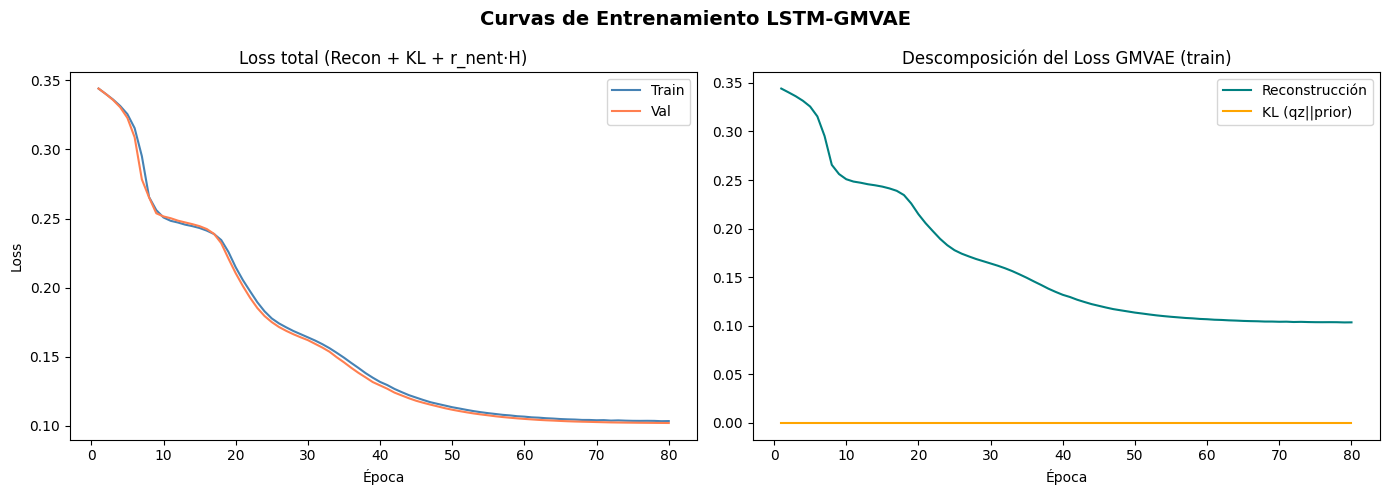

In [12]:
import matplotlib.pyplot as plt

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_arr = np.arange(1, N_EPOCHS + 1)

axes[0].plot(epochs_arr, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_arr, history['val_loss'], label='Val', color='coral')
axes[0].set_title('Loss total (Recon + KL + r_nent·H)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_arr, history['train_recon'], label='Reconstrucción', color='teal')
axes[1].plot(epochs_arr, history['train_kl'], label='KL (qz||prior)', color='orange')
axes[1].set_title('Descomposición del Loss GMVAE (train)')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.suptitle('Curvas de Entrenamiento LSTM-GMVAE', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{IMG_DIR}/01_curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Extraer Z y asignación de cluster
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

all_z, all_qy = [], []
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
with torch.no_grad():
    for xb, lb in full_loader:
        xb, lb = xb.to(DEVICE), lb.to(DEVICE)
        z_batch = encode_z(model, xb, lb)
        all_z.append(z_batch)
        if not USE_LSTM_AE:
            all_qy.append(encode_y(model, xb, lb))

Z = np.concatenate(all_z, axis=0)
if USE_LSTM_AE:
    from sklearn.cluster import KMeans
    km_temp = KMeans(n_clusters=K_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
    cluster_assign = km_temp.fit_predict(Z)
    qy_all = None
else:
    qy_all = np.concatenate(all_qy, axis=0)
    cluster_assign = qy_all.argmax(axis=1)
print(f'Espacio latente Z shape: {Z.shape}')
print(f'Asignación de clusters: {np.bincount(cluster_assign, minlength=K_CLUSTERS)}')

Espacio latente Z shape: (5000, 32)
Asignación de clusters: [1401  519 1286  108 1310  376]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


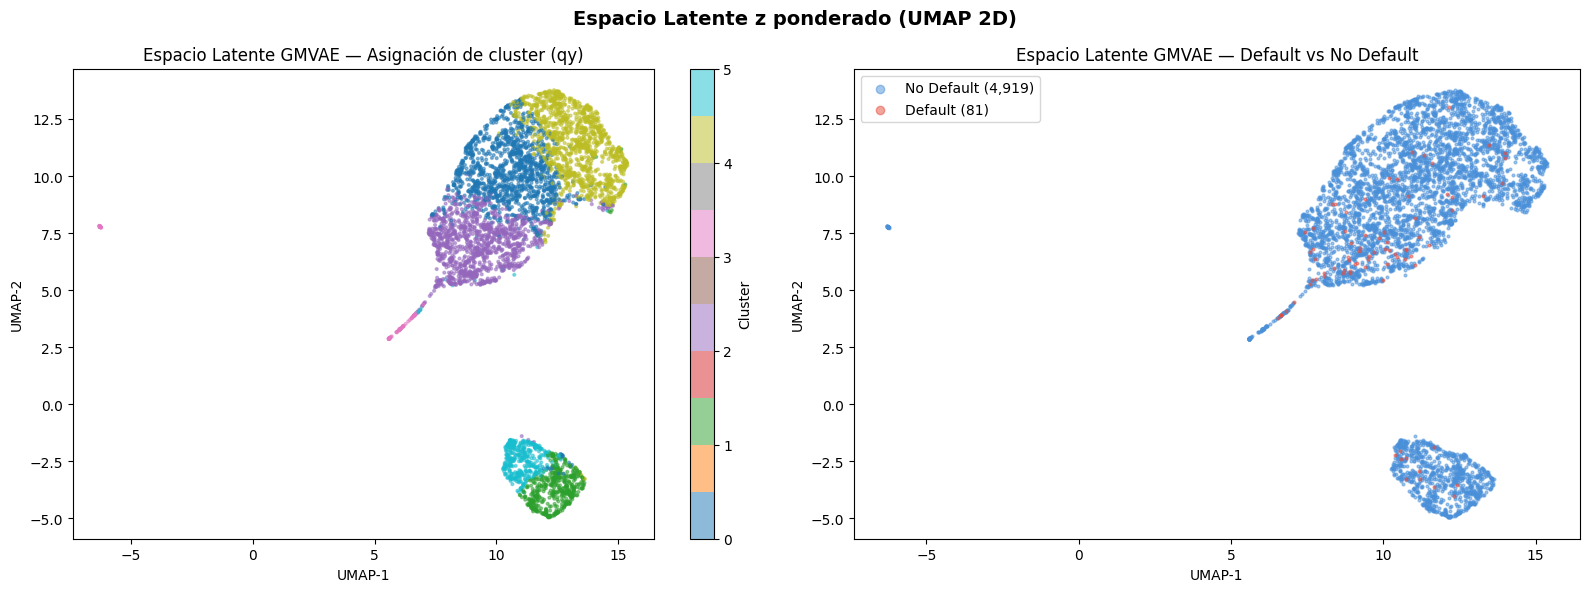

Distribución Default por cluster:
  Cluster 0: 1,401 préstamos, 0.6% default
  Cluster 1: 519 préstamos, 0.6% default
  Cluster 2: 1,286 préstamos, 3.9% default
  Cluster 3: 108 préstamos, 4.6% default
  Cluster 4: 1,310 préstamos, 0.5% default
  Cluster 5: 376 préstamos, 2.1% default


In [14]:
# UMAP del espacio latente: clusters GMVAE y Default
import umap

reducer = umap.UMAP(n_components=2, random_state=RANDOM_SEED, n_neighbors=30, min_dist=0.1)
Z_2d = reducer.fit_transform(Z)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por cluster GMVAE (qy.argmax)
sc0 = axes[0].scatter(Z_2d[:, 0], Z_2d[:, 1], c=cluster_assign, cmap='tab10', s=4, alpha=0.5)
cbar0 = plt.colorbar(sc0, ax=axes[0], ticks=range(K_CLUSTERS))
cbar0.set_label('Cluster')
axes[0].set_title('Espacio Latente GMVAE — Asignación de cluster (qy)')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# Por Default / No Default
colors = ['#4a90d9', '#e74c3c']
labels = ['No Default', 'Default']
for val, color, label in zip([0, 1], colors, labels):
    mask_y = y_target == val
    axes[1].scatter(Z_2d[mask_y, 0], Z_2d[mask_y, 1], s=4, alpha=0.5, c=color, label=f'{label} ({mask_y.sum():,})')
axes[1].set_title('Espacio Latente GMVAE — Default vs No Default')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')
axes[1].legend(markerscale=3)

plt.suptitle('Espacio Latente z ponderado (UMAP 2D)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{IMG_DIR}/02_espacio_latente_umap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Distribución Default por cluster:')
for c in range(K_CLUSTERS):
    m = cluster_assign == c
    if m.sum() > 0:
        def_rate = y_target[m].mean() * 100
        print(f'  Cluster {c}: {m.sum():,} préstamos, {def_rate:.1f}% default')

### Interpretación (Fannie Mae) — Selección de K y clusters

**Elbow + Silhouette:** El codo indica el punto donde añadir más clusters no reduce significativamente la inercia. El Silhouette sugiere el K con mejor separación. En Fannie Mae, K=2–4 suele ser suficiente para segmentos de riesgo (bajo/medio/alto).

**Tamaño y tasa de Default por cluster:** Los clusters con mayor % Default son candidatos a perfiles de alto riesgo. Los clusters grandes con bajo Default representan préstamos estables. Esta distribución permite priorizar monitoreo y pricing según el perfil.

## 9. Métricas de evaluación del modelo

Métricas para evaluar si el LSTM-GMVAE aprendió bien o sufrió posterior/mode collapse.

### Interpretación (Fannie Mae) — Heatmap de perfiles de riesgo

El heatmap muestra el **perfil de riesgo relativo** de cada cluster (filas) respecto a variables clave (columnas). Valores normalizados: 0 = perfil más favorable, 1 = más desfavorable.

**Cómo leerlo:** Un cluster con valores altos en LTV, DTI o morosidad y bajos en FICO se interpreta como perfil de alto riesgo. Los clusters con patrones opuestos son de bajo riesgo. Esto permite etiquetar cada cluster con un perfil de negocio (ej. "Estables", "Morosidad puntual", "Alto riesgo").

In [15]:
from sklearn.metrics import silhouette_score
from scipy.stats import entropy

# 1. Pérdidas finales (última época)
final_recon = history['train_recon'][-1]
final_kl = history['train_kl'][-1]
final_val_loss = history['val_loss'][-1]
print('=== Pérdidas finales ===')
print(f'  Recon (train): {final_recon:.4f} | KL (train): {final_kl:.4f} | Val loss: {final_val_loss:.4f}')

# 2. Balance de clusters (entropía de la distribución)
cluster_counts = np.bincount(cluster_assign, minlength=K_CLUSTERS)
cluster_probs = cluster_counts / cluster_counts.sum()
cluster_entropy = entropy(cluster_probs + 1e-10)
max_entropy = np.log(K_CLUSTERS)
norm_entropy = cluster_entropy / max_entropy if max_entropy > 0 else 0
print(f'\n=== Balance de clusters ===')
print(f'  Conteo por cluster: {cluster_counts.tolist()}')
print(f'  Entropía normalizada: {norm_entropy:.3f} (1=uniforme, 0=un solo cluster)')

# 3. Silhouette score (separación en espacio latente)
n_unique = len(np.unique(cluster_assign))
if n_unique >= 2 and (cluster_counts >= 2).sum() >= 2:
    sil = silhouette_score(Z, cluster_assign, metric='euclidean')
    print(f'\n=== Separación de clusters ===')
    print(f'  Silhouette score: {sil:.4f} (-1 a 1, mayor=mejor separación)')
else:
    sil = np.nan
    print(f'\n=== Separación de clusters ===')
    print('  Silhouette: N/A (se necesitan ≥2 clusters con ≥2 muestras)')

# 4. Default por cluster (si hay defaults)
n_default = y_target.sum()
if n_default > 0:
    print(f'\n=== Discriminación Default ===')
    for c in range(K_CLUSTERS):
        m = cluster_assign == c
        if m.sum() > 0:
            def_rate = y_target[m].mean() * 100
            print(f'  Cluster {c}: {def_rate:.1f}% default ({m.sum():,} préstamos)')
else:
    print(f'\n=== Discriminación Default ===')
    print('  Sin préstamos Default en la muestra (y_target todo 0)')

# 5. Diagnóstico: posterior collapse / mode collapse
print('\n=== Diagnóstico ===')
if final_kl < 0.02:
    print('  ⚠️ KL muy bajo → posible posterior collapse (encoder ignora z)')
elif final_kl > 2.0:
    print('  ⚠️ KL muy alto → prior y posterior muy distintos')
else:
    print('  ✓ KL en rango razonable')

if norm_entropy < 0.2:
    print('  ⚠️ Clusters desbalanceados → posible mode collapse (todo en un cluster)')
else:
    print('  ✓ Clusters con distribución razonable')

if not np.isnan(sil) and sil < 0:
    print('  ⚠️ Silhouette negativo → clusters mal definidos')
elif not np.isnan(sil):
    print(f'  ✓ Silhouette {sil:.3f} → clusters separados')

=== Pérdidas finales ===
  Recon (train): 0.1036 | KL (train): 0.0000 | Val loss: 0.1022

=== Balance de clusters ===
  Conteo por cluster: [1401, 519, 1286, 108, 1310, 376]
  Entropía normalizada: 0.876 (1=uniforme, 0=un solo cluster)

=== Separación de clusters ===
  Silhouette score: 0.1999 (-1 a 1, mayor=mejor separación)

=== Discriminación Default ===
  Cluster 0: 0.6% default (1,401 préstamos)
  Cluster 1: 0.6% default (519 préstamos)
  Cluster 2: 3.9% default (1,286 préstamos)
  Cluster 3: 4.6% default (108 préstamos)
  Cluster 4: 0.5% default (1,310 préstamos)
  Cluster 5: 2.1% default (376 préstamos)

=== Diagnóstico ===
  ⚠️ KL muy bajo → posible posterior collapse (encoder ignora z)
  ✓ Clusters con distribución razonable
  ✓ Silhouette 0.200 → clusters separados


## 10. Clustering en el espacio latente y análisis de perfiles

Usamos **K-means** y **Gaussian Mixture** sobre el espacio latente Z para obtener clusters interpretables. Luego analizamos los perfiles de riesgo por cluster.

---

## Interpretación de perfiles de riesgo (Fannie Mae)

### Caracterización de clusters por dominio de riesgo

| Perfil | Interpretación | Uso en gestión de cartera |
|--------|----------------|---------------------------|
| **Cluster bajo Default** | Préstamos con trayectorias estables, morosidad constante o nula. Típicamente: LTV moderado, DTI controlado, FICO alto. | Tarificación estándar, monitoreo rutinario. |
| **Cluster medio Default** | Trayectorias con episodios puntuales de morosidad (30–60 días) o volatilidad en UPB. | Alertas tempranas, revisión de condiciones. |
| **Cluster alto Default** | Concentración de préstamos que terminan en Default (06/09). Patrones de morosidad creciente o UPB estancado. | Pricing diferenciado, provisiones, estrategias de mitigación. |

### Variables clave para interpretar (Fannie Mae)

- **Current_Loan_Delinquency_Status:** Orden de morosidad (00=current, 01=30d, ..., XX=foreclosure). La evolución temporal es la señal más directa de riesgo.
- **Original_Loan_to_Value_Ratio_LTV, Debt-To-Income_DTI, Borrower_Credit_Score_at_Origination:** Variables estáticas de originación que explican el perfil inicial.
- **Current_Actual_UPB, Remaining_Months_to_Legal_Maturity:** Evolución de la exposición y del horizonte temporal.

### Impacto en pricing y monitoreo

La segmentación basada en embeddings permite:
1. **Pricing diferenciado:** Asignar spreads según el perfil de riesgo latente.
2. **Monitoreo proactivo:** Priorizar préstamos en clusters de alto riesgo para intervención temprana.
3. **Provisiones:** Estimar pérdidas esperadas por cluster para cumplimiento regulatorio.

In [16]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples

# Elegir K óptimo: probar K=2..10 y elegir por Silhouette
K_RANGE = range(2, 11)
sil_scores = []
inertias = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(Z)
    sil_scores.append(silhouette_score(Z, labels))
    inertias.append(km.inertia_)

# K óptimo = máximo Silhouette
K_OPT = list(K_RANGE)[np.argmax(sil_scores)]
print(f'K óptimo por Silhouette: {K_OPT} (score={max(sil_scores):.4f})')

# Entrenar K-means y GMM con K óptimo
kmeans = KMeans(n_clusters=K_OPT, random_state=RANDOM_SEED, n_init=10)
labels_km = kmeans.fit_predict(Z)

gmm = GaussianMixture(n_components=K_OPT, random_state=RANDOM_SEED, n_init=3)
labels_gmm = gmm.fit_predict(Z)
probs_gmm = gmm.predict_proba(Z)

# Usar labels de K-means como clustering principal (más estable que GMVAE si hay collapse)
clusters_final = labels_km
n_clusters = K_OPT

K óptimo por Silhouette: 3 (score=0.2694)


In [17]:
# Perfil de cada cluster: medias de variables clave (df_static en mismo orden que Z)
profile_cols = [c for c in STATIC_NUM if c in df_static.columns]
if not profile_cols:
    profile_cols = ['Original_Interest_Rate', 'Original_UPB', 'Borrower_Credit_Score_at_Origination']

profile_data = df_static[profile_cols].fillna(0).values

# Medias por cluster
cluster_profiles = np.zeros((n_clusters, len(profile_cols)))
cluster_sizes = np.zeros(n_clusters, dtype=int)
cluster_default_rate = np.zeros(n_clusters)

for c in range(n_clusters):
    m = clusters_final == c
    cluster_sizes[c] = m.sum()
    if m.sum() > 0:
        cluster_profiles[c] = profile_data[m].mean(axis=0)
        cluster_default_rate[c] = y_target[m].mean() * 100
    else:
        cluster_profiles[c] = np.nan
        cluster_default_rate[c] = np.nan

# Métricas del clustering K-means
sil_km = silhouette_score(Z, clusters_final)
print(f'Métricas clustering K-means (K={K_OPT}):')
print(f'  Silhouette: {sil_km:.4f}')
print(f'  Inercia: {kmeans.inertia_:.2f}')
print(f'\nTamaño por cluster: {cluster_sizes.tolist()}')

Métricas clustering K-means (K=3):
  Silhouette: 0.2694
  Inercia: 63308.51

Tamaño por cluster: [779, 1390, 2831]


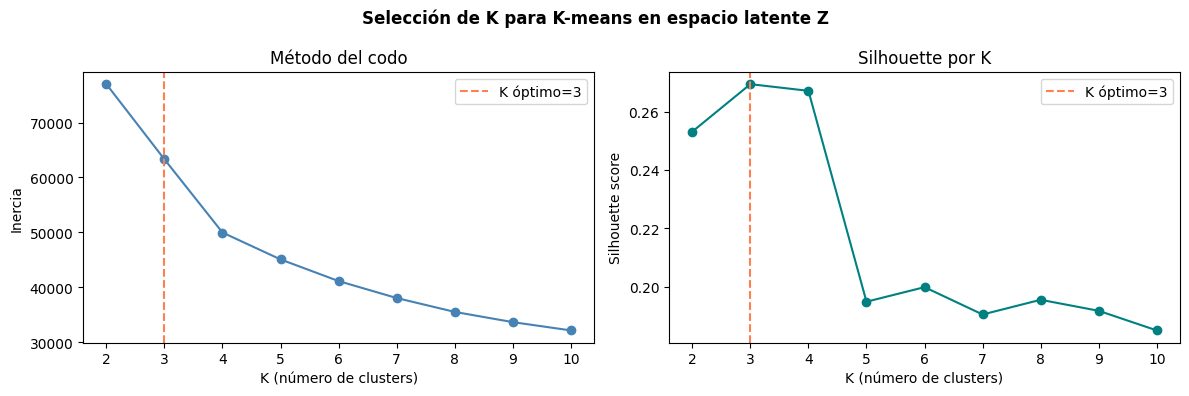

In [18]:
# --- Gráfica 1: Elbow + Silhouette para elegir K ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue')
axes[0].axvline(K_OPT, color='coral', linestyle='--', label=f'K óptimo={K_OPT}')
axes[0].set_xlabel('K (número de clusters)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].legend()

axes[1].plot(list(K_RANGE), sil_scores, 'o-', color='teal')
axes[1].axvline(K_OPT, color='coral', linestyle='--', label=f'K óptimo={K_OPT}')
axes[1].set_xlabel('K (número de clusters)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette por K')
axes[1].legend()
plt.suptitle('Selección de K para K-means en espacio latente Z', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{IMG_DIR}/03_seleccion_K_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Listar figuras guardadas (para revisión y análisis)
import glob
import os
figs = sorted(glob.glob(os.path.join(IMG_DIR, '*.png')))
print(f'Figuras guardadas en {IMG_DIR}:')
for f in figs:
    print(f'  - {os.path.basename(f)}')

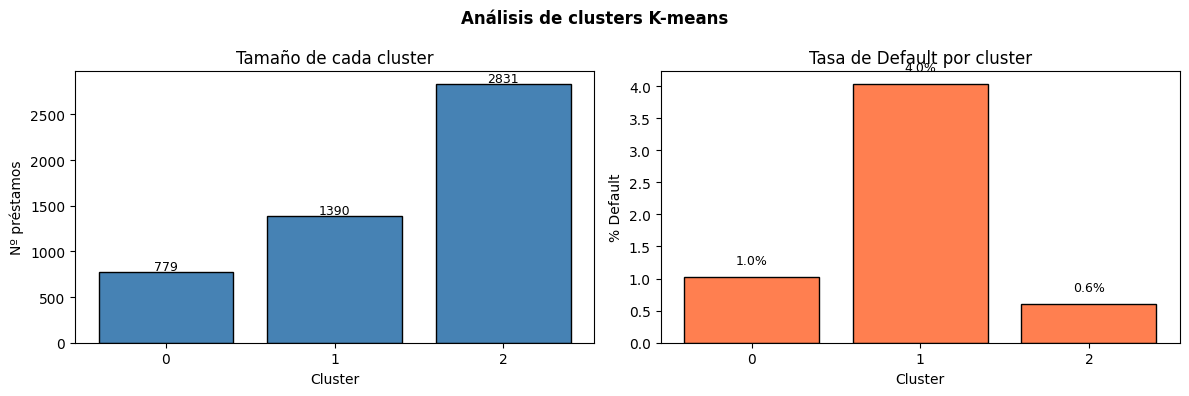

In [19]:
# --- Gráfica 2: Tamaño y Default rate por cluster ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x_pos = np.arange(n_clusters)
axes[0].bar(x_pos, cluster_sizes, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Nº préstamos')
axes[0].set_xticks(x_pos)
axes[0].set_title('Tamaño de cada cluster')
for i, v in enumerate(cluster_sizes):
    axes[0].text(i, v + 20, str(int(v)), ha='center', fontsize=9)

axes[1].bar(x_pos, cluster_default_rate, color='coral', edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('% Default')
axes[1].set_xticks(x_pos)
axes[1].set_title('Tasa de Default por cluster')
for i, v in enumerate(cluster_default_rate):
    if not np.isnan(v):
        axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)
plt.suptitle('Análisis de clusters K-means', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{IMG_DIR}/04_clusters_tamano_default.png', dpi=150, bbox_inches='tight')
plt.show()

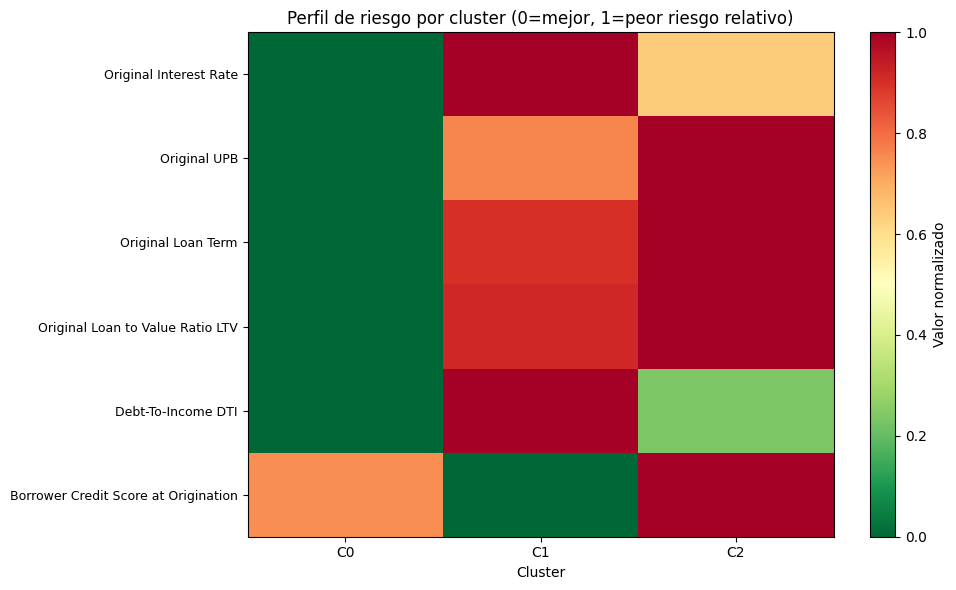

In [20]:
# --- Gráfica 3: Heatmap de perfiles (medias por cluster) ---
# Normalizar por columna para comparar
profile_norm = (cluster_profiles - np.nanmin(cluster_profiles, axis=0)) / (np.nanmax(cluster_profiles, axis=0) - np.nanmin(cluster_profiles, axis=0) + 1e-10)
profile_norm = np.nan_to_num(profile_norm, nan=0)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(profile_norm.T, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_xticks(np.arange(n_clusters))
ax.set_xticklabels([f'C{i}' for i in range(n_clusters)])
ax.set_yticks(np.arange(len(profile_cols)))
ax.set_yticklabels([c.replace('_', ' ') for c in profile_cols], fontsize=9)
ax.set_xlabel('Cluster')
ax.set_title('Perfil de riesgo por cluster (0=mejor, 1=peor riesgo relativo)')
plt.colorbar(im, ax=ax, label='Valor normalizado')
plt.tight_layout()
fig.savefig(f'{IMG_DIR}/05_perfil_riesgo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

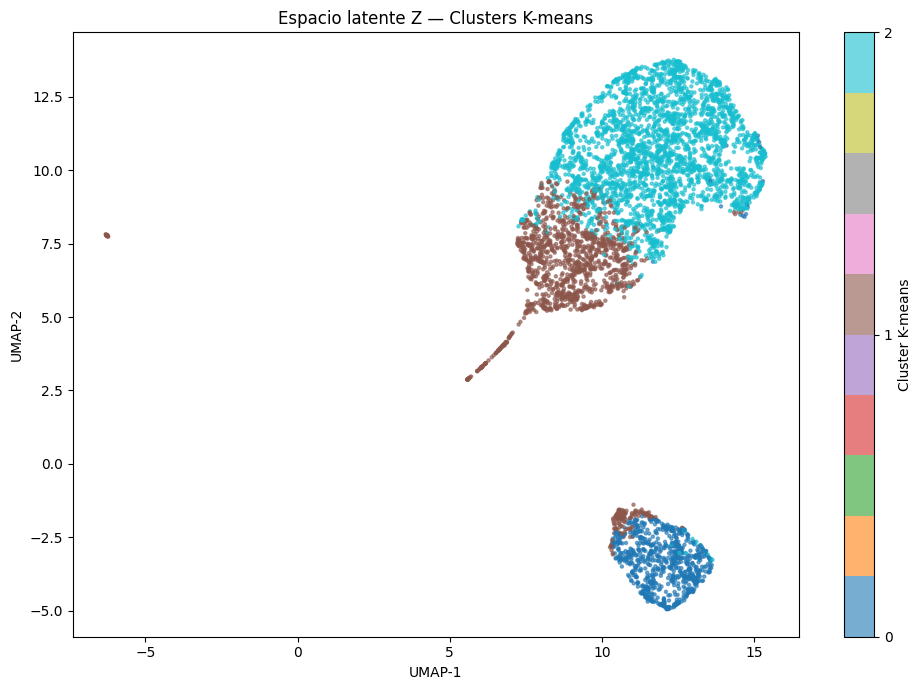

In [21]:
# --- Gráfica 4: UMAP coloreado por clusters K-means ---
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=clusters_final, cmap='tab10', s=5, alpha=0.6)
cbar = plt.colorbar(sc, ax=ax, ticks=range(n_clusters))
cbar.set_label('Cluster K-means')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_title('Espacio latente Z — Clusters K-means')
plt.tight_layout()
fig.savefig(f'{IMG_DIR}/06_espacio_latente_clusters_km.png', dpi=150, bbox_inches='tight')
plt.show()

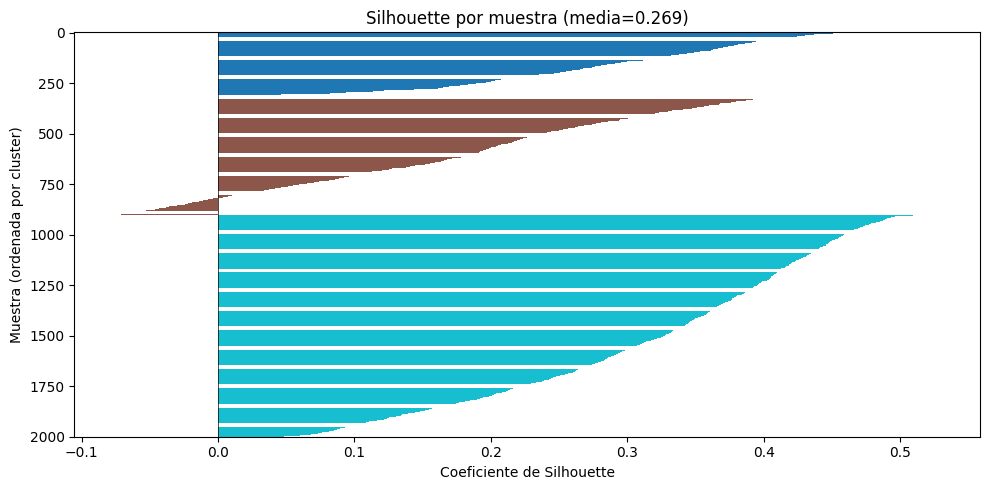

In [22]:
# --- Gráfica 5: Silhouette por muestra (ordenado por cluster) ---
if n_clusters >= 2 and (np.bincount(clusters_final, minlength=n_clusters) >= 2).sum() >= 2:
    sil_vals = silhouette_samples(Z, clusters_final)
    n_samples = len(sil_vals)
    max_show = min(2000, n_samples)
    if n_samples > max_show:
        idx = np.random.RandomState(RANDOM_SEED).choice(n_samples, max_show, replace=False)
        sil_show = sil_vals[idx]
        clust_show = clusters_final[idx]
    else:
        sil_show = sil_vals
        clust_show = clusters_final
    order = np.lexsort((-sil_show, clust_show))
    sil_sorted = sil_show[order]
    clust_sorted = clust_show[order]
    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos = np.arange(len(sil_sorted))
    cnorm = clust_sorted / max(clust_sorted.max(), 1)
    colors = plt.cm.tab10(cnorm)
    ax.barh(y_pos, sil_sorted, color=colors)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Coeficiente de Silhouette')
    ax.set_ylabel('Muestra (ordenada por cluster)')
    ax.set_title(f'Silhouette por muestra (media={sil_km:.3f})')
    ax.set_ylim(len(sil_sorted), -1)
    plt.tight_layout()
    fig.savefig(f'{IMG_DIR}/07_silhouette_por_muestra.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Silhouette por muestra omitido (se necesitan ≥2 clusters con ≥2 muestras)')

In [23]:
# --- Resumen: tabla de perfiles por cluster ---
tab = pd.DataFrame(cluster_profiles, columns=profile_cols, index=[f'Cluster {i}' for i in range(n_clusters)])
tab['N_préstamos'] = cluster_sizes
tab['% Default'] = cluster_default_rate
print('Perfil medio por cluster (variables de originación):')
print(tab.round(2).to_string())

Perfil medio por cluster (variables de originación):
           Original_Interest_Rate  Original_UPB  Original_Loan_Term  Original_Loan_to_Value_Ratio_LTV  Debt-To-Income_DTI  Borrower_Credit_Score_at_Origination  N_préstamos  % Default
Cluster 0                    7.74      95826.70              183.27                             64.40               28.89                                700.24          779       1.03
Cluster 1                    8.18     119065.54              341.13                             77.73               39.38                                654.28         1390       4.03
Cluster 2                    8.02     126460.97              358.83                             78.96               31.38                                715.79         2831       0.60


## 11. Guardar embeddings para uso en otros notebooks

Los embeddings y clusters se guardan en Drive. Carga en otro notebook con:
```python
data = np.load(f'{DRIVE_BASE}/mortgage-risk/ae_input/embeddings.npz')
Z = data['Z']; qy = data['qy']; cluster_assign = data['cluster_assign']
clusters_km = data['clusters_km']; y_target = data['y_target']; loan_ids = data['loan_ids']
```

In [24]:
# Guardar embeddings y clusters para uso en otros notebooks
embeddings_path = f'{OUTPUT_DIR}/embeddings.npz'
np.savez_compressed(
    embeddings_path,
    Z=Z,
    qy=qy_all,
    cluster_assign=cluster_assign,
    clusters_km=clusters_final,
    y_target=y_target,
    loan_ids=df_static[ID_COL].values,
)
print(f'Embeddings guardados en: {embeddings_path}')
print('Incluye: Z, qy (GMVAE) o None (LSTM-AE), cluster_assign, clusters_km (K-means), y_target, loan_ids')

Embeddings guardados en: /content/drive/MyDrive/mortgage-risk/ae_input/embeddings.npz
Incluye: Z, qy (GMVAE) o None (LSTM-AE), cluster_assign, clusters_km (K-means), y_target, loan_ids
